In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
BENCHMARK_SET = [0, 1, 2, 3]

NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 17
    ACTION_DIM = 6
    # AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_cheetah.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 1),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 24
    ACTION_DIM = 6
    # AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_walker.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 3),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            horizontal_velocity = states[..., [0]]
            sign_of_param = np.sign(params)
            horizontal_velocity = horizontal_velocity * sign_of_param
            rew = self.tolerance(horizontal_velocity,
                                lower=np.abs(params),
                                upper=float('inf'),
                                margin=np.abs(params),
                                value_at_margin=0,
                                sigmoid='linear')
            
        else: # Flip
            _SPIN_SPEED = 5
            angmomentum = states[..., [1]]
            rew = self.tolerance(angmomentum,
                                lower=_SPIN_SPEED,
                                upper=float('inf'),
                                margin=_SPIN_SPEED,
                                value_at_margin=0,
                                sigmoid='linear')

        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    

class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int) or isinstance(params, float):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            _STAND_HEIGHT = 1.2
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(horizontal_velocity,
                                            lower=params,
                                            upper=float('inf'),
                                            margin=params/2,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
            
        
        else: # flip
            _STAND_HEIGHT = 1.2
            _SPIN_SPEED = 5
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            angmomentum = states[..., [3]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(angmomentum,
                                            lower=_SPIN_SPEED,
                                            upper=float('inf'),
                                            margin=_SPIN_SPEED,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
        
        rew = stand_reward * (5*move_reward + 1) / 6    
                
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    
    
if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]
else:
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel0.1', 0.1),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'vel4', 4),
        (velocity_reward_function.compute_reward, 'vel8', 8),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]

In [8]:
# benchmark_id = 3
# benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
# y = benchmark_reward_function(
#     torch.tensor(aux[:, ::]),
#     benchmark_param
# )

# best_ids = y.mean(dim=-1).argsort()[-10:]
# worst_ids = y.mean(dim=-1).argsort()[:10]

# print(best_ids)

# _ = plt.plot(dataset['physics'][best_ids, :, 1].T, c='blue')
# _ = plt.plot(dataset['physics'][worst_ids, :, 1].T, c='red')

# # _ = plt.plot(aux[best_ids, :, 2].T, c='blue')
# # _ = plt.plot(aux[worst_ids, :, 2].T, c='red')

In [9]:
# env.reset()

# for i in range(0, 1000, 2):
    
#     with env.physics.reset_context():
#         env.physics.set_state(dataset['physics'][9569, i])
    
#     clear_output(True)

#     img = env.physics.render(camera_id=0)
#     plt.imshow(img)
#     plt.title(i)
    
#     # if y[6699, i] > 0.5:
#     #     plt.scatter(1, 1, c='green', s=1000)
    
#     # else:
#     #     plt.scatter(1, 1, c='red', s=1000)
    
#     plt.show()

In [10]:
BD_SIZE = 2000
SUBTRAJECTORY_SIZE = 50
SUBTRAJECTORY_SKIP = 10

In [312]:
# x = dataset_trajectories_cuda[::10, ::10].reshape(1, -1, STATE_DIM)
# x_physics = dataset_trajectories_cuda[::10, ::10].reshape(1, -1, STATE_DIM)

x = []
x_physics = []
x_aux = []
for _ in range(BD_SIZE):
    i = random.randint(0, 10000-1)
    j = random.randint(0,  1000-SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP)
    x.append(dataset_trajectories_cuda[i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    x_physics.append(dataset['physics'][i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    x_aux.append(aux[i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    
x = torch.stack(x).reshape(1, -1, STATE_DIM)
x_aux = torch.tensor(np.stack(x_aux))
x_physics = torch.tensor(np.stack(x_physics)).reshape(BD_SIZE, SUBTRAJECTORY_SIZE, -1)

tensor([1020, 1761,  263, 1788,  333,  266,  981,  679, 1608,  822])
tensor([ 978,  214, 1121,   73,  464,  591,  439,  148, 1401, 1581])


/tmp/ipykernel_11495/1313009762.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_aux),


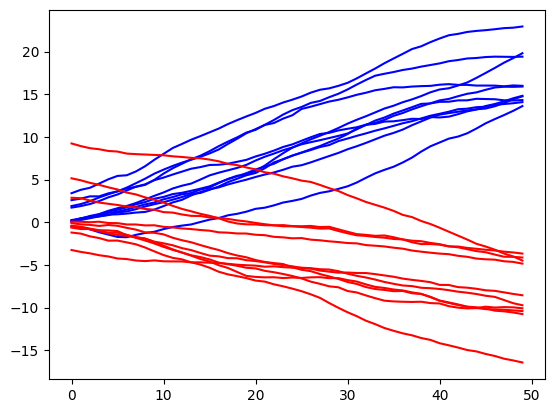

In [313]:
benchmark_id = 3
benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
y = benchmark_reward_function(
    torch.tensor(x_aux),
    benchmark_param
)

best_ids = y.mean(dim=-1).argsort()[-10:]
worst_ids = y.mean(dim=-1).argsort()[:10]

print(best_ids)
print(worst_ids)

_ = plt.plot(x_physics[best_ids, :, 0].T, c='blue')
_ = plt.plot(x_physics[worst_ids, :, 0].T, c='red')

In [314]:
# env.reset()

# for i in range(1000):
    
#     with env.physics.reset_context():
#         env.physics.set_state(x_physics[766, i])
    
#     clear_output(True)

#     img = env.physics.render(camera_id=0)
#     plt.imshow(img)
#     plt.title(i)
    
#     # if y[6699, i] > 0.5:
#     #     plt.scatter(1, 1, c='green', s=1000)
    
#     # else:
#     #     plt.scatter(1, 1, c='red', s=1000)
    
#     plt.show()

---

In [315]:
class MiniMLPs(nn.Module):
    def __init__(self, N):
        super(MiniMLPs, self).__init__()
        self.N = N
        self.C = 0
        self.mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(STATE_DIM, 32),
                nn.Sigmoid(),
                nn.Linear(32, 32),
                nn.Sigmoid(),
                nn.Linear(32, 1),
                nn.Tanh()
            )
            for i in range(N)
        ])

    def forward(self, x, ids=None):
        rewards = []
        with torch.no_grad():

            if ids is None:
                ids = list(range(len(self.mlps)))
            
            for i in ids:
                r = self.mlps[i](x)
                rewards.append(r)
        
        rewards = torch.concat(rewards)
        
        # rewards = rewards / (1+rewards.abs())
        
        return rewards

---

In [316]:
def correlation_matrix(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute correlation matrix between rows of A (N, dim) and B (M, dim).
    Returns (N, M).
    """
    assert A.dim() == 2 and B.dim() == 2
    assert A.size(1) == B.size(1), "Last dimension must match"

    # Center the rows
    A_centered = A - A.mean(dim=1, keepdim=True)
    B_centered = B - B.mean(dim=1, keepdim=True)

    # Normalize to unit variance
    A_norm = A_centered / (A_centered.norm(dim=1, keepdim=True) + 1e-8)
    B_norm = B_centered / (B_centered.norm(dim=1, keepdim=True) + 1e-8)

    # Correlation = cosine similarity after mean-centering
    corr = A_norm @ B_norm.T
    return corr

In [317]:
import torch

def kendall_tau_matrix(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute Kendall's tau correlation matrix between rows of A and rows of B.
    
    A: (N, M) tensor
    B: (K, M) tensor
    Returns: (N, K) tensor with Kendall's tau values
    """
    N, M = A.shape
    K = B.shape[0]
    result = torch.empty((N, K), dtype=torch.float32, device=A.device)

    # Upper triangular mask to avoid duplicate pairs within a row
    mask = torch.triu(torch.ones(M, M, dtype=bool, device=A.device), 1)

    for i in range(N):
        xi = A[i]
        diff_x = xi.unsqueeze(0) - xi.unsqueeze(1)
        sign_x = torch.sign(diff_x[mask])

        for j in range(K):
            yj = B[j]
            diff_y = yj.unsqueeze(0) - yj.unsqueeze(1)
            sign_y = torch.sign(diff_y[mask])

            concordant = (sign_x * sign_y > 0).sum()
            discordant = (sign_x * sign_y < 0).sum()

            tau = (concordant - discordant).float() / (concordant + discordant).float()
            result[i, j] = tau

    return result




import torch

def kendall_signature(X: torch.Tensor):
    """
    Convert rows of X into Kendall sign signatures.
    Each row of X -> vector of signs for all pairwise differences.
    """
    N, M = X.shape
    idx_i, idx_j = torch.triu_indices(M, M, offset=1)
    diffs = X[:, idx_i] - X[:, idx_j]  # (N, P)
    return torch.sign(diffs)  # concordant=+1, discordant=-1, tie=0

def kendall_tau_matrix_2(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute Kendall's tau-b correlation matrix between rows of A and B.
    A: (N, M)
    B: (K, M)
    Returns: (N, K)
    """
    sigA = kendall_signature(A)   # (N, P)
    sigB = kendall_signature(B)   # (K, P)
    P = sigA.shape[1]

    dot = sigA @ sigB.T  # (N, K), numerator (C - D)

    # Effective pair counts per row (ignoring ties)
    countA = sigA.abs().sum(dim=1, keepdim=True)  # (N, 1)
    countB = sigB.abs().sum(dim=1, keepdim=True)  # (K, 1)

    denom = torch.sqrt(countA @ countB.T).clamp(min=1.0)

    return dot / denom


In [318]:
def jaccard_similarity_matrix(A, B):
    """
    A: LongTensor of shape (N, dim) containing IDs
    B: LongTensor of shape (M, dim) containing IDs
    Returns: FloatTensor of shape (N, M) with Jaccard similarity
    """
    N, dim_A = A.shape
    M, dim_B = B.shape
    
    # Ensure no duplicates per row
    A_unique = [set(row.tolist()) for row in A]
    B_unique = [set(row.tolist()) for row in B]
    
    # Preallocate similarity matrix
    sim_matrix = torch.zeros((N, M), dtype=torch.float32)
    
    for i, a_row in enumerate(A_unique):
        for j, b_row in enumerate(B_unique):
            intersection = len(a_row.intersection(b_row))
            union = len(a_row.union(b_row))
            sim_matrix[i, j] = intersection / union if union > 0 else 0.0
    
    return sim_matrix

In [319]:

# A = torch.tensor([
#     [1, 2, 3],
#     [4, 5, 6]
# ])
# B = torch.tensor([
#     [3, 2, 7],
#     [5, 6, 8],
#     [1, 9, 3]
# ])

def jaccard_similarity_matrix_2(A, B):

    # Shapes
    N, dim = A.shape
    M, _ = B.shape

    # Expand A and B for broadcasting: (N, 1, dim) vs (1, M, dim)
    A_exp = A.unsqueeze(1)           # (N, 1, dim)
    B_exp = B.unsqueeze(0)           # (1, M, dim)

    # Compare pairwise equality across dim
    # Result: (N, M, dim) boolean tensor
    eq = (A_exp.unsqueeze(-1) == B_exp.unsqueeze(-2))  # (N, M, dim, dim)

    # Count matches: reduce last two axes
    inter_counts = eq.any(-1).sum(-1)
    union_counts = 2*dim - inter_counts

    # return inter_counts / union_counts
    return inter_counts / dim

In [320]:
def update_container(container_mlps, container_bds, container_fs, threshold=0.5, K=10):
    
    
    sort_values, sort_indices = container_fs.sort(descending=True)

    new_container_mlps_list = []
    new_container_bds = torch.zeros_like(container_bds)
    new_container_fs = torch.zeros_like(container_fs)
    
    y2 = torch.zeros((container_bds.shape[0], K), dtype=torch.float32, device=device)
    
    NEW_C = 0
    for i in sort_indices:
        
        
        if NEW_C == 50:
            break
        
        if len(new_container_mlps_list) == 0:
            new_container_mlps_list.append(
                [(container_mlps.mlps[i][l].weight, container_mlps.mlps[i][l].bias) for l in [0, 2, 4]]
            )
            new_container_bds[NEW_C] = container_bds[i]
            new_container_fs[NEW_C] = container_fs[i]
            y2[NEW_C] = new_container_bds[NEW_C].argsort(dim=-1).float()[-K:]
            # y2[NEW_C] = torch.arange(100).float().to(device)
            NEW_C += 1
            
            
        else: # Contrainer already has some solutions
            # distances = (container_bds[i] - new_container_bds[:NEW_C]).norm(dim=-1, p=2)
            # distances = correlation_matrix(container_bds[i].unsqueeze(0), new_container_bds)
            y1 = container_bds[i].unsqueeze(0).argsort(dim=-1)[:, -K:].float()
            distances = jaccard_similarity_matrix_2(y1, y2)
            
            if distances.sort(descending=True).values[0, 0] < threshold:
                new_container_mlps_list.append(
                    [(container_mlps.mlps[i][l].weight, container_mlps.mlps[i][l].bias) for l in [0, 2, 4]]
                )
                new_container_bds[NEW_C] = container_bds[i]
                new_container_fs[NEW_C] = container_fs[i]
                y2[NEW_C] = new_container_bds[NEW_C].argsort(dim=-1).float()[-K:]
                # y2[NEW_C] = torch.arange(100).float().to(device)
                NEW_C += 1
            
            
    container_mlps.C = NEW_C

    for i in range(len(new_container_mlps_list)):
        for l_i, l in enumerate([0, 2, 4]):
            container_mlps.mlps[i][l].weight.data = new_container_mlps_list[i][l_i][0]
            container_mlps.mlps[i][l].bias.data = new_container_mlps_list[i][l_i][1]
            
    return container_mlps, new_container_bds[:NEW_C], new_container_fs[:NEW_C]

In [321]:
N_children = 5
lr = 0.05

batch_size = 32
k_neighbors = 1


In [371]:
container_mlps = MiniMLPs(N=500).to(device)
children_mlps = MiniMLPs(N=500).to(device)


scores = []
expressivities = []

container_bds = torch.zeros((0, 2), dtype=torch.float32)
container_fs = torch.zeros((0,), dtype=torch.float32)

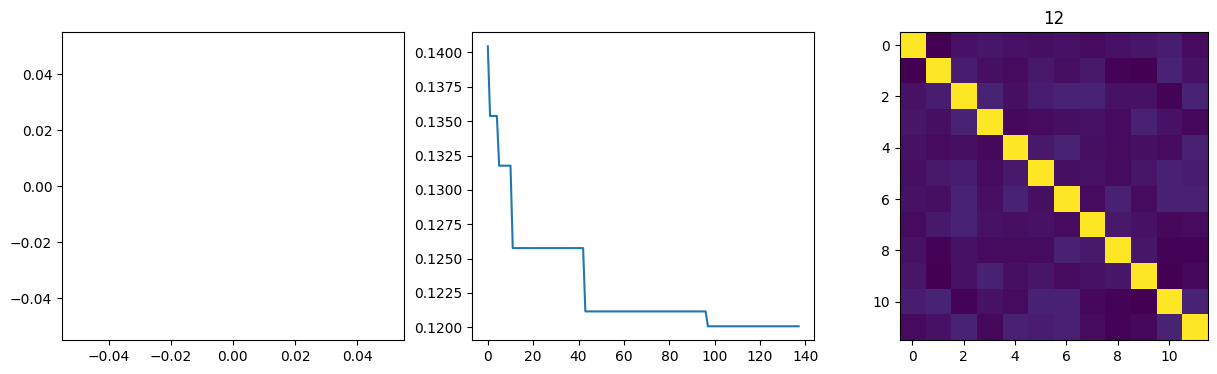

  0%|          | 0/10000 [00:00<?, ?it/s]


In [373]:
for step in tqdm(range(10000)):
    
    
    C = len(container_bds)  
    
    if C == 0:
        parents_ids = list(range(batch_size))
        children_ids = list(range(batch_size*N_children))
    else:
        parents_ids = [random.randint(0, C-1) for _ in range(batch_size)]
        children_ids = list(range(batch_size*N_children))
        for i, parent_id in enumerate(parents_ids):
            for j in range(N_children):
                for l in [0, 2, 4]:
                    children_mlps.mlps[i*N_children + j][l].weight.data = container_mlps.mlps[parent_id][l].weight.data + torch.normal(0, lr, container_mlps.mlps[parent_id][l].weight.shape, device=device)
                    children_mlps.mlps[i*N_children + j][l].bias.data =   container_mlps.mlps[parent_id][l].bias.data + torch.normal(0, lr, container_mlps.mlps[parent_id][l].bias.shape, device=device)
                        
    
    # Evaluation of individuals in offspring population:
    r = children_mlps(x, children_ids)

    # break
    
    r = r.reshape(-1, BD_SIZE, SUBTRAJECTORY_SIZE)
    
    children_bds = r.mean(dim=-1)      
        
    signal = r.mean(dim=-1).std(dim=-1)
    noise = r.std(dim=-1).mean(dim=-1)
    # noise = torch.ones_like(noise)
    expressivity = signal / (noise + 1e-9)
    # expressivity = torch.clip(expressivity, min=0, max=0.5)
    # expressivity = torch.ones_like(expressivity)
    # expressivity = 1 / (noise + 1e-9)
    
    
    # expressivity = dataset_trajectories_cuda[
    #     children_bds.argsort(dim=-1)[:, -10:].flatten().cpu(),
    #     :, 17
    # ].to(device).mean(dim=-1).reshape(N_children*batch_size, 10).mean(dim=-1)
    # expressivity = torch.ones((N_children*batch_size,), dtype=torch.float32)
    
    
    # Try to update the container:
    
    if len(container_bds) == 0:
        container_bds = children_bds[[0]]
        container_fs = expressivity[[0]]
        
        children_ids = children_ids[:-1]
        children_bds = children_bds[1:]
        expressivity = expressivity[1:]
        
        for l in [0, 2, 4]:
            container_mlps.mlps[0][l].weight.data = children_mlps.mlps[0][l].weight.data
            container_mlps.mlps[0][l].bias.data = children_mlps.mlps[0][l].bias.data
        container_mlps.C += 1
        
    
    


    # Check the children to be added to the container:

    # break
    
    K = 100
    threshold = 0.1
    
    y2 = container_bds.argsort(dim=-1)[:, -K:].float()
    
    for child_id in children_ids:
        # print(child_id)
        
        
        y1 = children_bds[child_id].unsqueeze(0).argsort(dim=-1)[:, -K:].float()
        distances = jaccard_similarity_matrix_2(y1, y2)
        # distances = (container_bds - children_bds[child_id]).norm(dim=-1, p=2)
        
        # break
        
        
        sort_values, sort_indices = distances.sort(descending=True)

        k_nearest_distance_to_child = sort_values[0, :k_neighbors].mean(dim=-1)
        nearest_id_to_child = sort_indices[0, 0]
        
        # print(k_nearest_distance_to_child)
                                    
        if k_nearest_distance_to_child <= threshold and container_mlps.C < container_mlps.N-1: # The child is novel, so we add it to the container   
            C = container_mlps.C
            for l in [0, 2, 4]:
                container_mlps.mlps[C][l].weight.data = children_mlps.mlps[child_id][l].weight.data
                container_mlps.mlps[C][l].bias.data = children_mlps.mlps[child_id][l].bias.data
            container_mlps.C += 1
                    
            container_bds = torch.concat((container_bds, children_bds[child_id].unsqueeze(0)))
            container_fs = torch.concat((container_fs, expressivity[child_id].unsqueeze(0)))
            
            y2 = container_bds.argsort(dim=-1)[:, -K:].float()
            
            
            


    
    # scores.append(score[top_population_idx].mean().item())
    
    
    # break
    # print(container_bds.shape)
    
    
    
    # continue
    
    expressivities.append(container_fs.mean().item())
    
    # print(container_bds.shape)
    
    
    # break
        
    if step % 20 == 0:
        clear_output(True)
        # print(container_mlps.C)
        
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(scores)
        
        # _ = axs[2].hist(bd[0].cpu(), bins=100) 
        # axs[2].imshow(row_cross_correlation(bd).cpu(), vmin=-1, vmax=1)
        # axs[1].set_xlim([-1, 1]) 
        
        axs[1].plot(expressivities)
        # axs[1].set_ylim([0, 1]) 
                
        # axs[2].imshow(correlation_matrix(container_bds, container_bds).cpu(), vmin=-1, vmax=1)
        y = container_bds.argsort(dim=-1).float()[:, -K:]
        axs[2].imshow(jaccard_similarity_matrix_2(y, y).cpu(), vmin=0, vmax=1)
        axs[2].set_title(f'{len(container_bds)}')
        
        plt.show()
    
    break

(array([48., 42., 16., 18., 15.,  9.,  4.,  6.,  0.,  2.]),
 array([0.07089597, 0.14182873, 0.21276149, 0.28369427, 0.35462701,
        0.42555979, 0.49649256, 0.56742531, 0.63835806, 0.70929086,
        0.78022361]),
 <BarContainer object of 10 artists>)

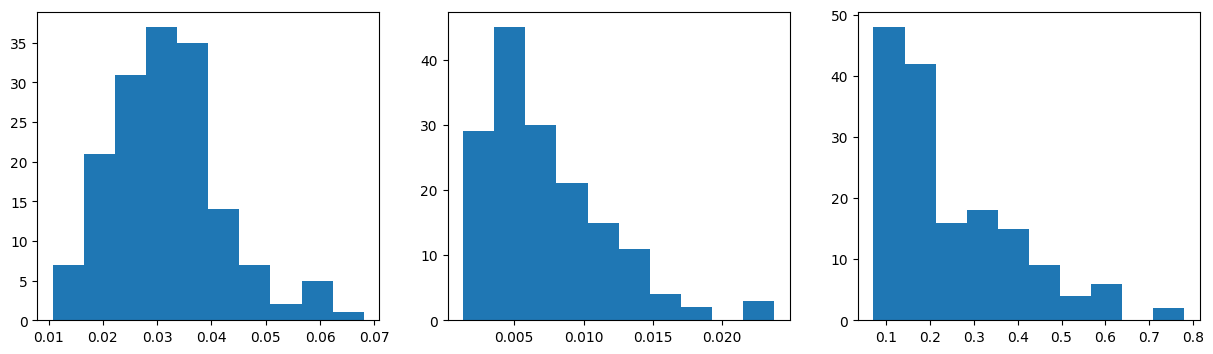

In [325]:
fig, axs  = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(noise.flatten().cpu())
axs[1].hist(signal.flatten().cpu())
axs[2].hist(expressivity.flatten().cpu())

(-1.0, 1.0)

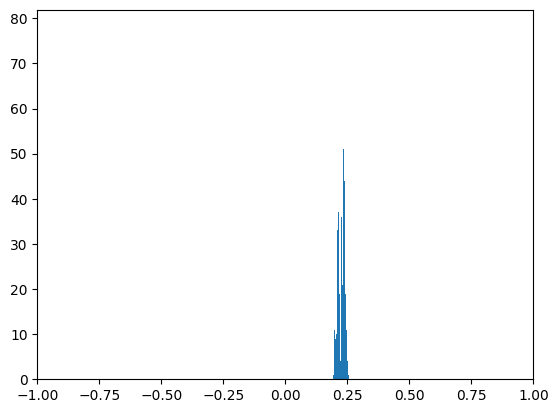

In [290]:
_ = plt.hist(container_bds[1].cpu(), bins=100)
plt.xlim([-1, 1])

(-1.0, 1.0)

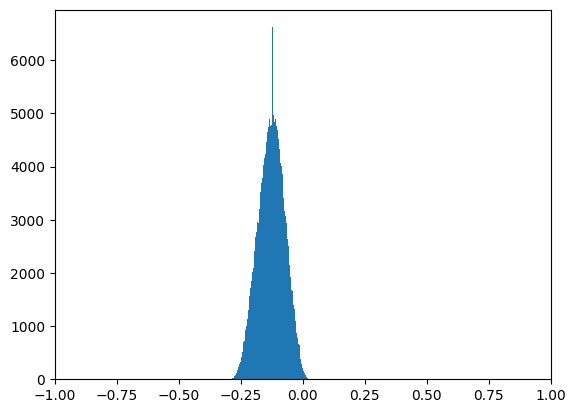

In [291]:
_ = plt.hist(r[20].flatten().cpu(), bins=100)
plt.xlim([-1, 1])

In [292]:
# ma_ = -10000
# for i in range(len(container_bds)):
#     ids = container_bds[i].argsort()[-50:].cpu() * 10
#     f = dataset['physics'][ids, -1, 0].mean()
#     if f > ma_:
#         print(i, f)
#         ma_ = f
#     # break

In [293]:
y = dataset_trajectories_cuda[::10, ::10]
r = container_mlps(y, list(range(container_mlps.C)))
bds = r.reshape(container_mlps.C, 1000, 100).mean(dim=-1)

dataset['physics'][bds.argsort(dim=-1)[:, -50:].flatten().cpu() * 10, -1, 0].reshape(-1, 50).mean(axis=-1).argsort()

array([ 2,  4, 10,  6,  3,  9,  5,  1, 11,  7,  8,  0])

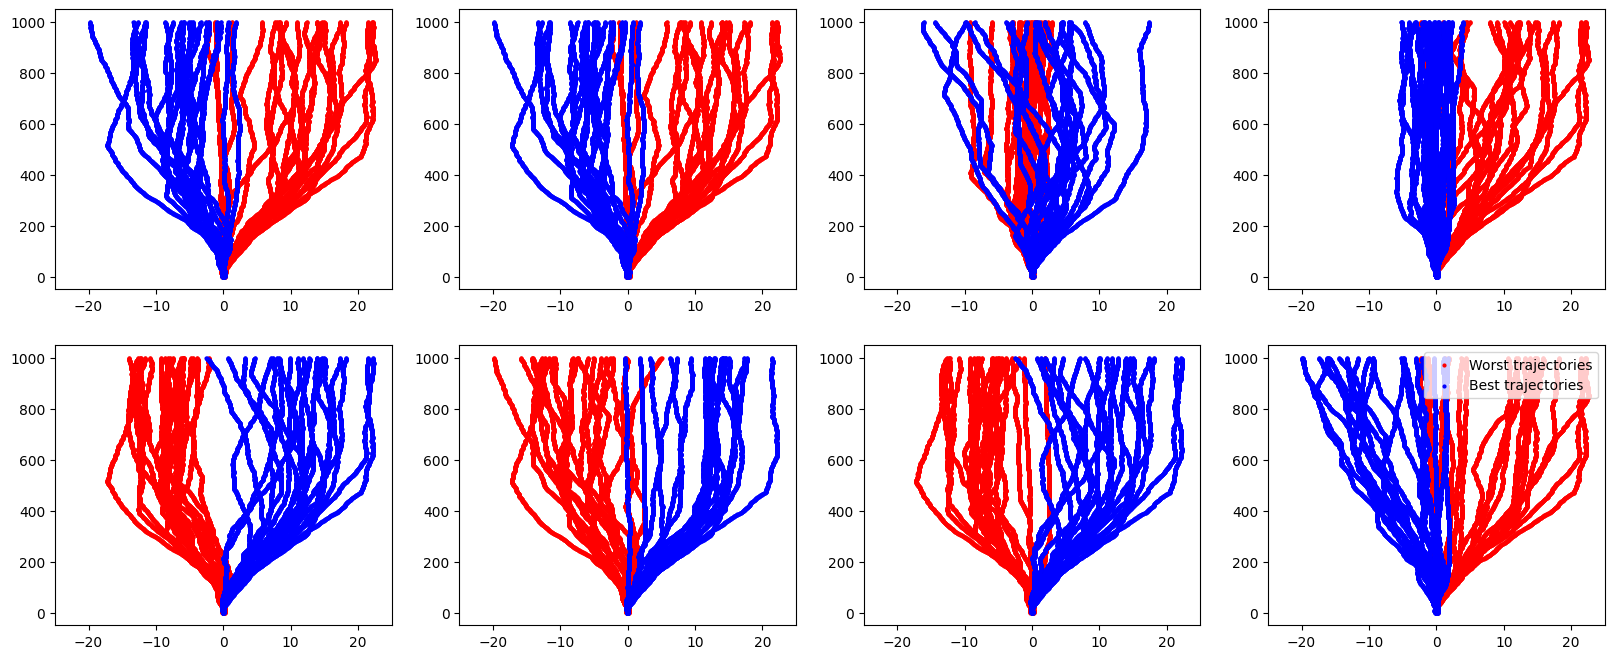

In [377]:
y = dataset_trajectories_cuda[::10, ::10]
min_, max_ = y.reshape(-1, 17).min(dim=0).values, y.reshape(-1, 17).max(dim=0).values
y = (y - min_) / (max_ - min_)

# model = nn.Sequential(
#     nn.Linear(17, 32),
#     nn.ReLU(),
#     nn.Linear(32, 32),
#     nn.ReLU(),
#     nn.Linear(32, 1),
# ).to(device)

# r = model(y[..., :])
# r = r.reshape(-1, 1000, 100)
# bds = r.mean(dim=-1)  





r = container_mlps(y, list(range(container_mlps.C)))
bds = r.reshape(container_mlps.C, 1000, 100).mean(dim=-1)
# bds = r_.reshape(1, 1000, 100).mean(dim=-1)

fig, axs = plt.subplots(2, 4, figsize=(5*4, 4*2))
axs = axs.flatten()

for i in range(min(len(axs), container_mlps.C)):

    ids = bds[i].argsort()[:20].cpu()*10
    axs[i].scatter(
        dataset['physics'][ids, :, 0],
        torch.arange(1000).reshape(1, -1).repeat(20, 1),
        c='red', s=4,
        label='Worst trajectories'
    )


    ids = bds[i].argsort()[-20:].cpu()*10
    axs[i].scatter(
        dataset['physics'][ids, :, 0],
        torch.arange(1000).reshape(1, -1).repeat(20, 1),
        c='blue', s=4,
        label='Best trajectories'
    )
    
    axs[i].set_xlim([-25, 25])

plt.legend()

In [90]:
benchmark_id = 0

benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
r_ = benchmark_reward_function(
    torch.tensor(x_aux),
    benchmark_param
)

# y1 = container_bds.argsort(dim=-1).float()[:1, -K:]
y1_bds = r_.reshape(x_aux.shape[0], x_aux.shape[1]).mean(dim=-1).unsqueeze(0).to(device)
y1_bds
container_bds


/tmp/ipykernel_11495/853188960.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_aux),


tensor([[-0.2923, -0.2742, -0.2930,  ..., -0.3133, -0.3009, -0.2771],
        [-0.2900, -0.2948, -0.2909,  ..., -0.2871, -0.2915, -0.2961],
        [ 0.0440,  0.0406,  0.0453,  ...,  0.0448,  0.0450,  0.0434],
        ...,
        [-0.1963, -0.2016, -0.1996,  ..., -0.2001, -0.1982, -0.2004],
        [-0.0186, -0.0208, -0.0184,  ..., -0.0187, -0.0190, -0.0200],
        [ 0.0121,  0.0182,  0.0159,  ...,  0.0181,  0.0125,  0.0175]],
       device='cuda:0')

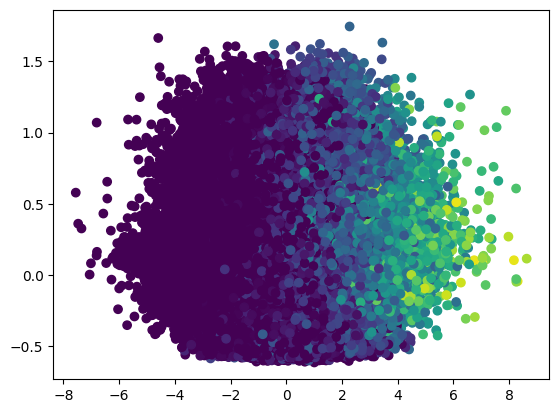

In [91]:
benchmark_id = 3
benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
r_ = benchmark_reward_function(
    torch.tensor(aux[::10, ::10]),
    benchmark_param
)
# plt.scatter(dataset_trajectories[::10, ::10, 8], aux[::10, ::10, 0], c=r_)
plt.scatter(dataset_trajectories[::10, ::10, 8], dataset_trajectories[::10, ::10, 0], c=r_)

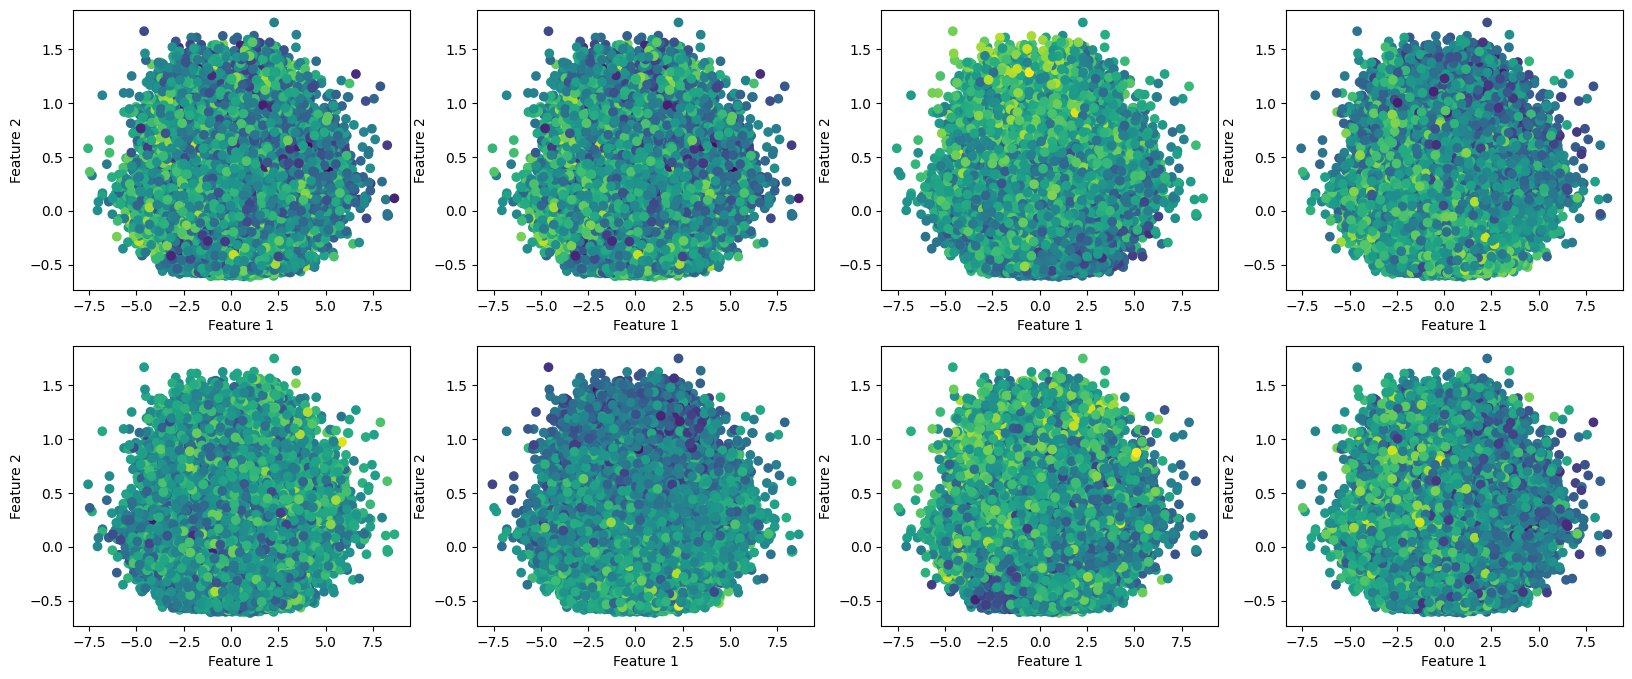

In [380]:
reshaped_r = r.reshape(-1, 1000, 100)

fig, axs = plt.subplots(2, 4, figsize=(5*4, 4*2))
axs = axs.flatten()

for i in range(min(len(axs), container_mlps.C)):
    axs[i].scatter(dataset_trajectories[::10, ::10, 8], dataset_trajectories[::10, ::10, 0], c=reshaped_r[i].cpu().detach())
    axs[i].set_xlabel('Feature 1')
    axs[i].set_ylabel('Feature 2')
    # break

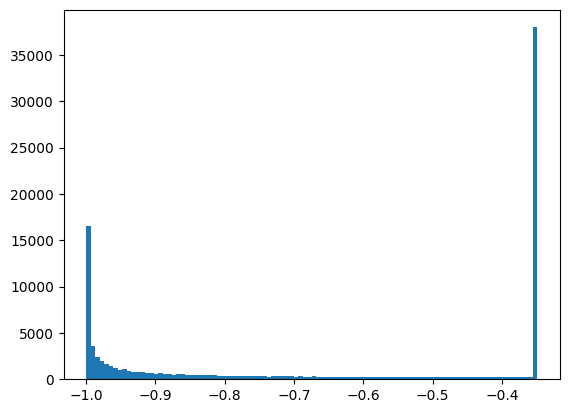

In [143]:
_ = plt.hist(reshaped_r[3].flatten().cpu(), bins=100)

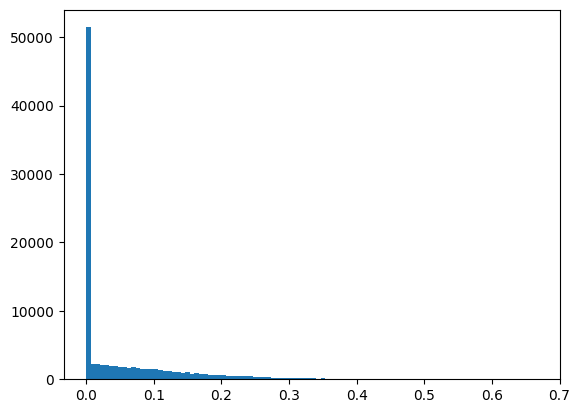

In [322]:
_ = plt.hist(r_.flatten().cpu(), bins=100)

In [33]:
[s for s in mlps.mlps[0][0].__dir__() if not '__' in s]

NameError: name 'mlps' is not defined

In [104]:
r_

tensor([[0.0080, 0.0015, 0.0000,  ..., 0.0143, 0.0255, 0.0206],
        [0.0023, 0.0318, 0.0038,  ..., 0.0000, 0.0000, 0.0279],
        [0.0036, 0.0000, 0.0126,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0071,  ..., 0.0971, 0.1026, 0.1429],
        [0.0000, 0.0258, 0.1158,  ..., 0.1305, 0.0000, 0.0000]])